In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../src/data/raw/balanced_10m_reviews.csv", nrows=10000000)

print(df.shape)
df.head()
df.info(memory_usage='deep')

(10000000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 20 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   game                            object 
 1   author_steamid                  int64  
 2   author_num_games_owned          int64  
 3   author_num_reviews              int64  
 4   author_playtime_forever         float64
 5   author_playtime_last_two_weeks  float64
 6   author_playtime_at_review       int64  
 7   author_last_played              float64
 8   language                        object 
 9   review                          object 
 10  timestamp_created               int64  
 11  timestamp_updated               int64  
 12  voted_up                        int64  
 13  votes_up                        int64  
 14  votes_funny                     int64  
 15  weighted_vote_score             float64
 16  comment_count                   int64  
 17  steam_purch

In [3]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 20 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   game                            object 
 1   author_steamid                  int64  
 2   author_num_games_owned          int64  
 3   author_num_reviews              int64  
 4   author_playtime_forever         float64
 5   author_playtime_last_two_weeks  float64
 6   author_playtime_at_review       int64  
 7   author_last_played              float64
 8   language                        object 
 9   review                          object 
 10  timestamp_created               int64  
 11  timestamp_updated               int64  
 12  voted_up                        int64  
 13  votes_up                        int64  
 14  votes_funny                     int64  
 15  weighted_vote_score             float64
 16  comment_count                   int64  
 17  steam_purchase            

,game,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access
count,10000000,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,10000000,10000000,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
unique,60325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,9404984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Counter-Strike 2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,english,best game ever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,316328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000000,7071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,7.656120e+16,1.704155e+02,3.654682e+01,1.376186e+04,7.097686e+01,6.776852e+03,1.623218e+09,NaN,NaN,1.581663e+09,1.586267e+09,7.000000e-01,3.446545e+00,8.461176e+04,2.264795e-01,4.296881e+02,6.580337e-01,3.543760e-02,1.251688e-01
std,NaN,3.867642e+08,5.959365e+02,2.785691e+02,4.422054e+04,5.391088e+02,2.548519e+04,9.466730e+07,NaN,NaN,8.750168e+07,8.638615e+07,4.582576e-01,4.991723e+01,1.906289e+07,2.576815e-01,1.358188e+06,4.743684e-01,1.848832e-01,3.309102e-01
min,NaN,7.656120e+16,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,8.640000e+04,NaN,NaN,1.287182e+09,1.287182e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,7.656120e+16,0.000000e+00,3.000000e+00,4.270000e+02,0.000000e+00,2.300000e+02,1.587174e+09,NaN,NaN,1.517037e+09,1.526129e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,NaN,7.656120e+16,0.000000e+00,8.000000e+00,1.841000e+03,0.000000e+00,8.220000e+02,1.656223e+09,NaN,NaN,1.603253e+09,1.607046e+09,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
75%,NaN,7.656120e+16,1.370000e+02,2.200000e+01,8.063000e+03,0.000000e+00,3.284000e+03,1.689062e+09,NaN,NaN,1.652158e+09,1.656518e+09,1.000000e+00,1.000000e+00,0.000000e+00,5.012255e-01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent
}).head(20)

,missing_count,missing_percent
game,0,0.0
author_steamid,0,0.0
author_num_games_owned,0,0.0
author_num_reviews,0,0.0
author_playtime_forever,0,0.0
author_playtime_last_two_weeks,0,0.0
author_playtime_at_review,0,0.0
author_last_played,0,0.0
language,0,0.0
review,0,0.0


In [5]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna("unknown")

In [6]:
sample_df = df.sample(500_000, random_state=42)

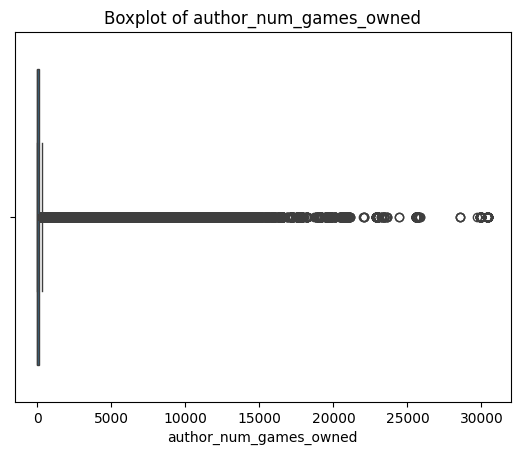

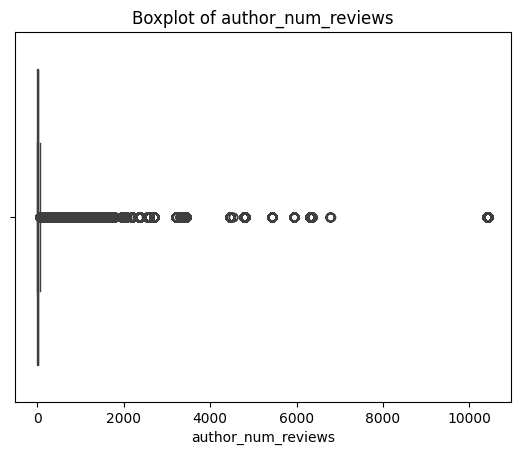

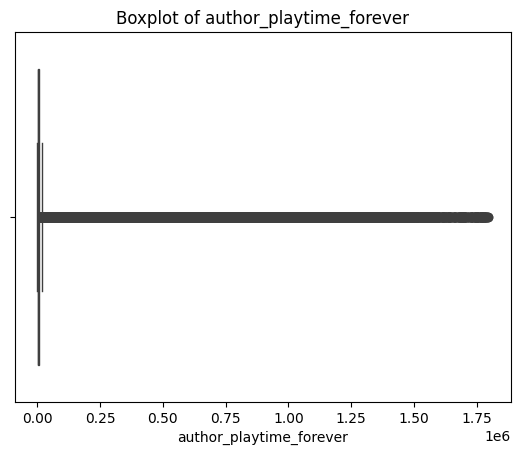

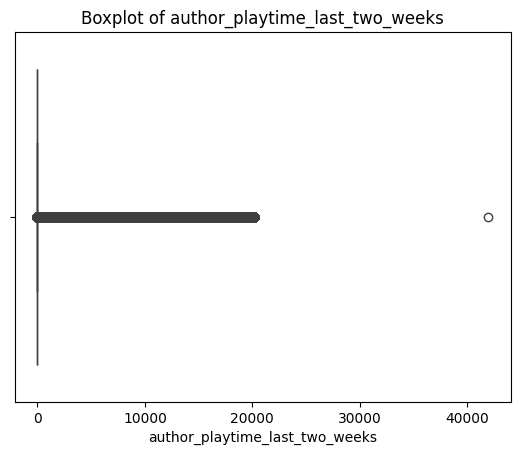

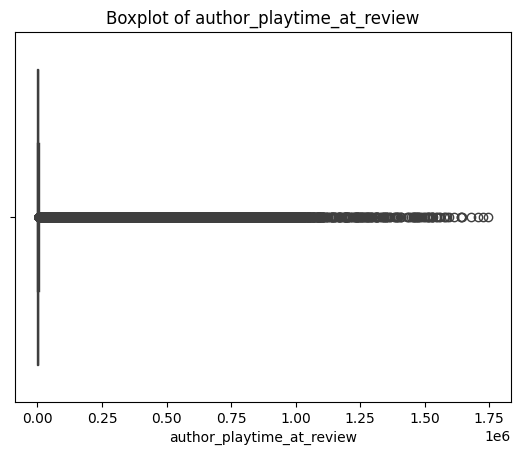

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols = df.select_dtypes(include=np.number).columns.drop('author_steamid', errors='ignore')

for col in numeric_cols[:5]:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [8]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])

In [9]:
df['review_length'] = df['review'].astype(str).apply(len)

if 'recommended' in df.columns:
    df['recommended'] = df['recommended'].astype(int)

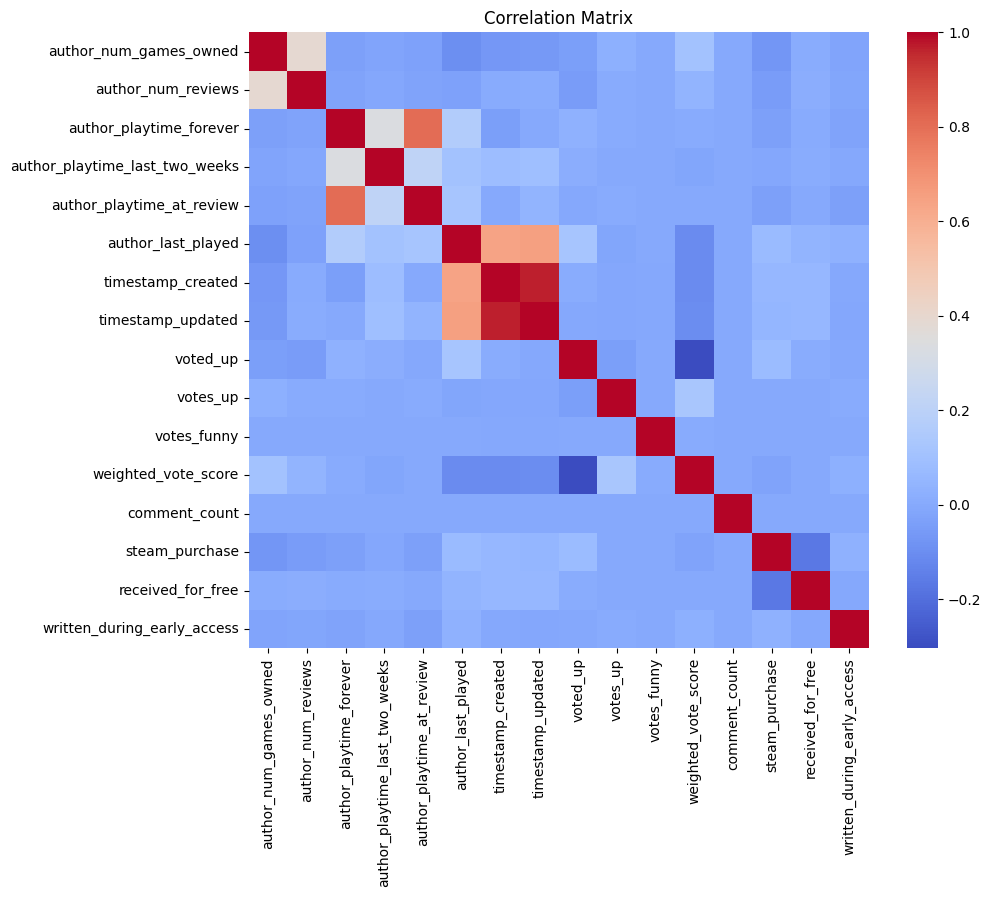

In [10]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

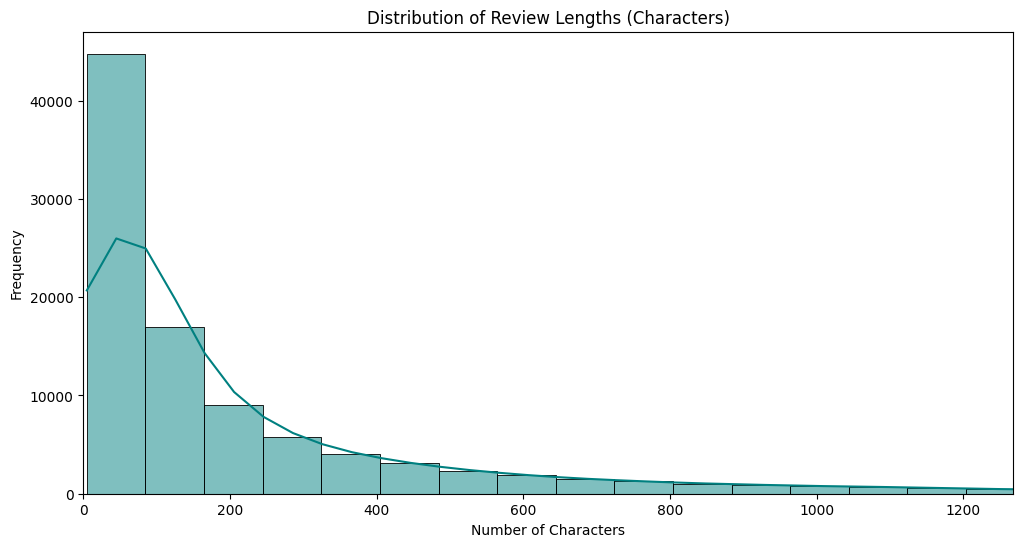

Average Review Length: 312.15


In [ ]:
df['review_len'] = df['review'].fillna('').apply(len)


plt.figure(figsize=(12, 6))
sns.histplot(df['review_len'].sample(100000), bins=100, kde=True, color='teal')
plt.title("Distribution of Review Lengths (Characters)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.xlim(0, df['review_len'].quantile(0.95)) 
plt.show()

print(f"Average Review Length: {df['review_len'].mean():.2f}")

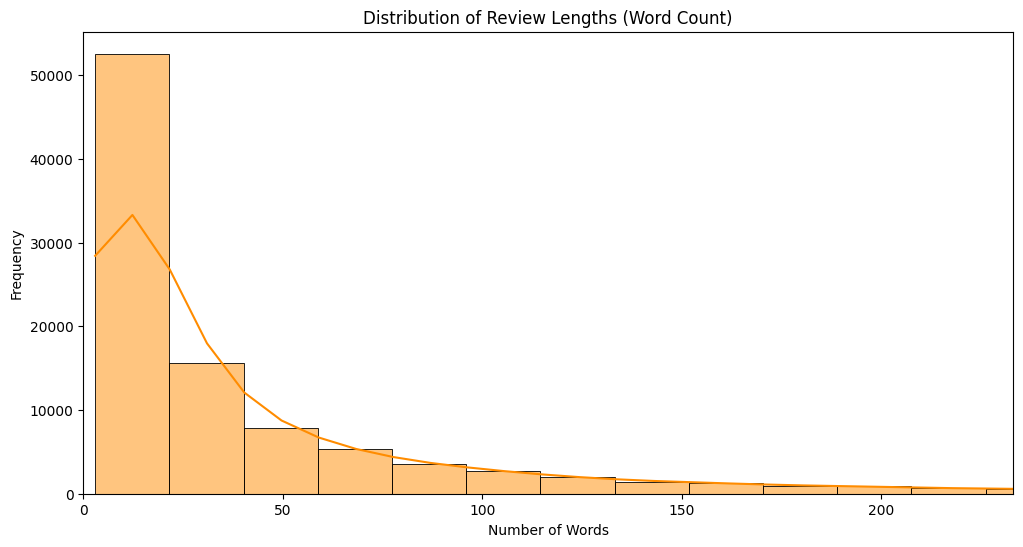

Average Word Count: 57.50
Median Word Count: 19.00
95th Percentile (Suggested LSTM maxlen): 233.00


In [12]:
#super expensive, keep sampling low
df['word_count'] = df['review'].fillna('').str.split().str.len()

plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'].sample(100000), bins=100, kde=True, color='darkorange')
plt.title("Distribution of Review Lengths (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.xlim(0, df['word_count'].quantile(0.95)) 
plt.show()

print(f"Average Word Count: {df['word_count'].mean():.2f}")
print(f"Median Word Count: {df['word_count'].median():.2f}")